In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import mido
from lookup_delta_3d import *
from mm_part_to_part import *
from mm_chord_to_chord_dd import *
import IPython.display as ipd
from midi_helpers import *

In [2]:
#get the lookup table
#copied this from the delta_3d_lookup.py file

train_dir = os.path.join('jsb_chorales_in_c', 'train')
lookup_table_bass = get_delta_3d_lookup(train_dir)
lookup_table_tenor = get_delta_3d_lookup(train_dir, part='tenor')
lookup_table_alto = get_delta_3d_lookup(train_dir, part='alto')

alto_to_alto_transition, tenor_to_tenor_transition, bass_to_bass_transition = train_part_to_part_markov(train_dir)

Parsing CSVs: 100%|██████████| 229/229 [00:00<00:00, 2113.99song/s]


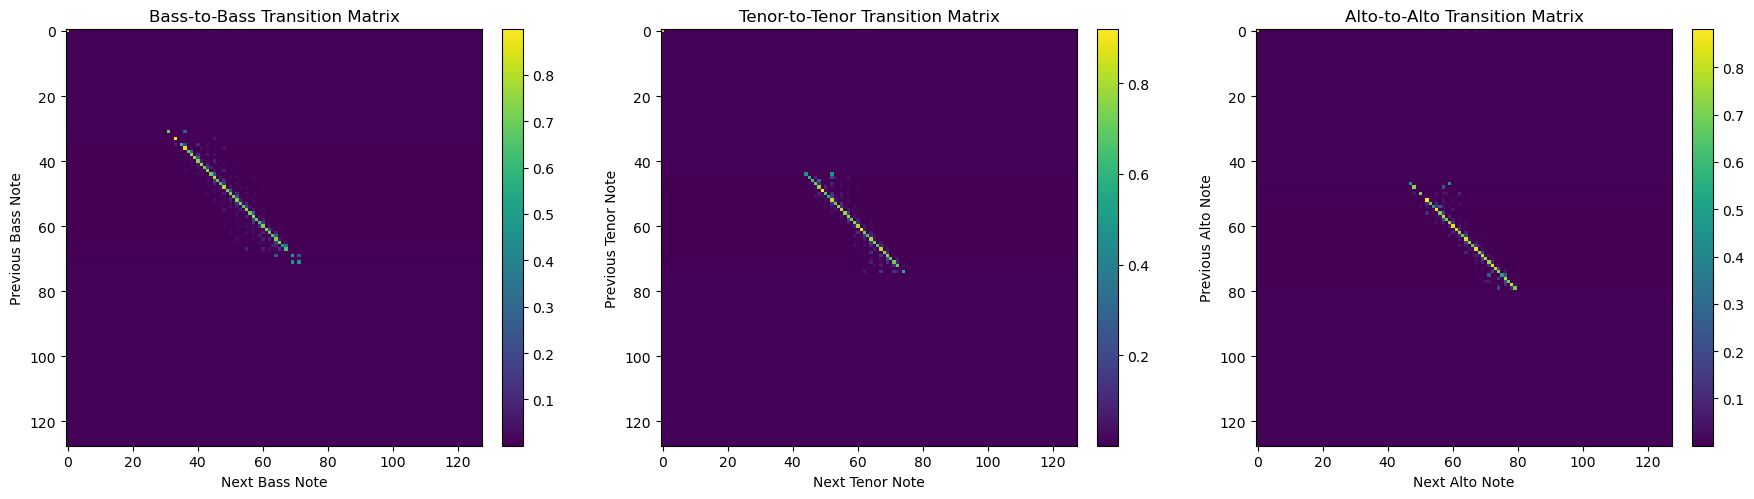

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

im0 = axs[0].imshow(bass_to_bass_transition)
axs[0].set_title("Bass-to-Bass Transition Matrix")
axs[0].set_xlabel("Next Bass Note")
axs[0].set_ylabel("Previous Bass Note")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(tenor_to_tenor_transition)
axs[1].set_title("Tenor-to-Tenor Transition Matrix")
axs[1].set_xlabel("Next Tenor Note")
axs[1].set_ylabel("Previous Tenor Note")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

im2 = axs[2].imshow(alto_to_alto_transition)
axs[2].set_title("Alto-to-Alto Transition Matrix")
axs[2].set_xlabel("Next Alto Note")
axs[2].set_ylabel("Previous Alto Note")
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [4]:
def get_part_line(lookup_table, A, soprano_input, l=1):
    """
    Inputs
      - lookup_table: a matrix containing log probabilities P(delta | soprano_{n-1}, part_n) of size (128, 128, 2*num_semitones+2), indexed (part, prev_soprano, delta)
      - A: an 128 x 128 matrix specifying transitions of part's notes between moments in time
      - soprano input -- a 1d array of soprano midi notes
        
    Outputs
      - part_est: the supporting part line
    """
    ### INSERT CODE BELOW ###
    
    #grab dimensions and initialize cumulative cost matrix
    N = np.size(soprano_input)
    M = 128

    #make sure A and pi has no zeros
    A = np.clip(A, 1E-9, 1) # we don't even have to renormalize?

    D = np.zeros((M, N))
    B = np.zeros((M, N))

    #initialize probabilities
    D[:, 0] = np.sum(lookup_table[:, :, :], axis=(1,2)) #should add log(P(O_1 | S_1)) term
    #just writes total probability of being in that bass note (sums over soprano and delta dimensions)

    #lookup table is indexed (bass, prev_soprano, delta)
    #walk through the matrix
    for j in range(1, N):
      delta = soprano_input[j] - soprano_input[j-1]
      for i in range(M):
        D[i, j] = np.max(D[:, j-1] + np.log(A[:, i])+ l*lookup_table[:, int(soprano_input[j-1]), delta_2_index(delta)])
        B[i,j] = np.argmax(D[:, j-1] + np.log(A[:, i])+ l*lookup_table[:, int(soprano_input[j-1]), delta_2_index(delta)])

        #best_index = int(B[i,j])
        #print(np.log(A[best_index, i]), l*lookup_table[best_index, int(soprano_input[j-1]), delta_2_index(delta)])
  

    part_est = np.zeros(N, dtype = int)
    endpoint = np.argmax(D[:, -1])
    part_est[-1] = endpoint

    for i in range(N-1)[::-1]:
      part_est[i] = B[int(part_est[i+1]), i+1]

    return part_est

In [5]:
from pathlib import Path
import csv

test_dir = Path("jsb_chorales_in_c") / "test"
out_dir = Path("generated")
out_dir.mkdir(parents=True, exist_ok=True)

paths = sorted(p for p in test_dir.glob("chorale_*.csv") if not p.name.endswith("_chords.csv"))
for path in paths:
    path_str = str(path)
    S, _, _, _ = csv_to_tracks(path_str)
    B = get_part_line(lookup_table_bass, bass_to_bass_transition, S, l=1)
    A = get_part_line(lookup_table_alto, alto_to_alto_transition, S, l=1)
    T = get_part_line(lookup_table_tenor, tenor_to_tenor_transition, S, l=1)
    out_path = out_dir / path.name
    with out_path.open("w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["note0", "note1", "note2", "note3"])
        for row in zip(S, A, T, B):
            w.writerow([int(row[0]), int(row[1]), int(row[2]), int(row[3])])
    print(out_path)

print(f"Wrote {len(paths)} chorales to {out_dir}/")
# S, A, T, B still refer to the last test chorale (for optional preview cells below)


generated/chorale_305.csv
generated/chorale_306.csv
generated/chorale_307.csv
generated/chorale_308.csv
generated/chorale_309.csv
generated/chorale_310.csv
generated/chorale_311.csv
generated/chorale_312.csv
generated/chorale_313.csv
generated/chorale_314.csv
generated/chorale_315.csv
generated/chorale_316.csv
generated/chorale_317.csv
generated/chorale_318.csv
generated/chorale_319.csv
generated/chorale_320.csv
generated/chorale_321.csv
generated/chorale_322.csv
generated/chorale_323.csv
generated/chorale_324.csv
generated/chorale_325.csv
generated/chorale_326.csv
generated/chorale_327.csv
generated/chorale_328.csv
generated/chorale_329.csv
generated/chorale_330.csv
generated/chorale_331.csv
generated/chorale_332.csv
generated/chorale_333.csv
generated/chorale_334.csv
generated/chorale_335.csv
generated/chorale_336.csv
generated/chorale_337.csv
generated/chorale_338.csv
generated/chorale_339.csv
generated/chorale_340.csv
generated/chorale_341.csv
generated/chorale_342.csv
generated/ch

In [6]:
arrays_to_midi((S, A, T, B))

Successfully saved to output.mid


In [8]:
midi_arrays_to_ipd((S, A, T, B), bpm=240, save_wav=True, wav_filename=str(out_dir / "preview.wav"))

# Now try with chord as hidden state (instead of A, T, B independently)

In [94]:
def chordseq_to_parts(chordseq, idx_to_chord):
    """
    Inputs:
        - chordseq: Nx1 arr of chord indices
        - idx_to_chord: dict mapping chord_idx(int) --> (A, T, B) (tuple of midi ints)
    Outputs:
        - part_A: Nx1 arr of ints, corresponding to alto line (midi notes)
        - part_T: Nx1 arr of ints, corresponding to tenor line (midi notes)
        - part_B: Nx1 arr of ints, corresponding to base line (midi notes)
    """
    N = len(chordseq)
    part_A = np.zeros(N, dtype = int)
    part_T = np.zeros(N, dtype = int)
    part_B = np.zeros(N, dtype = int)

    for i in range(len(chordseq)):
        chord_idx = chordseq[i]
        chord = idx_to_chord[chord_idx]
        (A, T, B) = chord
        part_A[i] = A
        part_T[i] = T
        part_B[i] = B

    return (part_A, part_T, part_B)

In [95]:
# from lookup_delta_3d import *
train_dir = os.path.join('jsb_chorales', 'train')
path = os.path.join('jsb_chorales_in_c', 'test', 'chorale_312.csv')

S, _, _, _ = csv_to_tracks(path)
chord_to_idx, idx_to_chord, chord_to_chord = get_chord_dict(train_dir)
# print(chord_to_idx[72, 67, 60])
# plt.imshow(chord_to_chord)

Parsing CSVs: 100%|██████████| 229/229 [00:03<00:00, 64.89song/s]


 total chords seen: 55228


In [96]:
lookup_table_chord = get_delta_3d_lookup_chord(train_dir, chord_to_idx)
chordseq = get_part_line(lookup_table_chord, chord_to_chord, S, l=1)

In [97]:
print(chordseq)
A, T, B = chordseq_to_parts(chordseq, idx_to_chord)
# print(A)
arrays_to_midi((S, A, T, B))

[   9    9    9    9    9    9    9    9    9    9    9    9    9    9
    9    9    9    9    9    9    9    9    9    9    9    9    9    9
    9    9    9    8    8    8    8    8    8    8    8    8    8    8
    8    8    8    8    8    8    8    8    8    8    8    8    8    8
    8    8    8    8    8    8    8    8    8    8    8    8    8    8
    8    8    8    8    8    8   36   36   36    8    8    8    8    8
    8    8    8    8    8    8    8    8    8    8    8    9    9    9
    9    8    8    8    8    8    8    8    8    8    8    8    8    8
    8    8    8    8    8    8    8    9    9    9    9    9    9    9
    9    9    9    9    9    9    9    9    9    9    9    9    9    9
    9    9    9    8   31   31   31 1640  771   15   15   15   15   15
   15   15   15   15   15   41   41   41   41   41   41   41   41   41
   43   43   43   41   41   41   41   41   41   41   41   41   41   41
   41   15   15   15   15   15   15   15   15   15   15   15   15   15]
Succe

In [98]:
midi_arrays_to_ipd((S, A, T, B), bpm=120, save_wav=True, wav_filename="output.wav")